1. Setup và Load Data

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False # Tránh lỗi hiển thị dấu trừ

# 1. Load dữ liệu từ file đã gộp
df = pd.read_csv('../data/processed/hcmc_merged_cleaned.csv')
df['datetime_local'] = pd.to_datetime(df['datetime_local'])
# Loại bỏ timezone để tránh lỗi vẽ biểu đồ
if df['datetime_local'].dt.tz is not None:
    df['datetime_local'] = df['datetime_local'].dt.tz_localize(None)
df.set_index('datetime_local', inplace=True)

print("✅ Đã load dữ liệu thành công!")
display(df.head())

✅ Đã load dữ liệu thành công!


,pm1,pm25,relativehumidity,temperature,um003,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,wind_direction_10m,boundary_layer_height
datetime_local,,,,,,,,,,,,
2024-11-19 18:00:00,18.600000,29.139999,62.800000,27.172000,3519.660059,30.9,59.0,0.1,1007.6,1.0,211.0,150.0
2024-11-19 19:00:00,18.700000,29.150000,57.816667,29.025001,3363.499980,29.3,68.0,0.0,1008.4,4.9,204.0,245.0
2024-11-19 20:00:00,20.533333,31.783333,57.333333,29.130000,3903.650004,26.6,77.0,0.2,1009.5,2.8,105.0,95.0
2024-11-19 21:00:00,20.016667,30.950000,56.883334,29.161667,3583.299988,26.6,79.0,0.1,1010.0,4.0,309.0,85.0
2024-11-19 22:00:00,19.679167,30.216667,56.395833,29.043750,3495.024984,26.8,79.0,0.0,1009.9,3.2,164.0,55.0


2. Univariate EDA (Phân tích đơn biến)

--- Kiểm tra giá trị thiếu ---
pm1                      0
pm25                     0
relativehumidity         0
temperature              0
um003                    0
temperature_2m           0
relative_humidity_2m     0
precipitation            0
surface_pressure         0
wind_speed_10m           0
wind_direction_10m       0
boundary_layer_height    0
hour                     0
dtype: int64


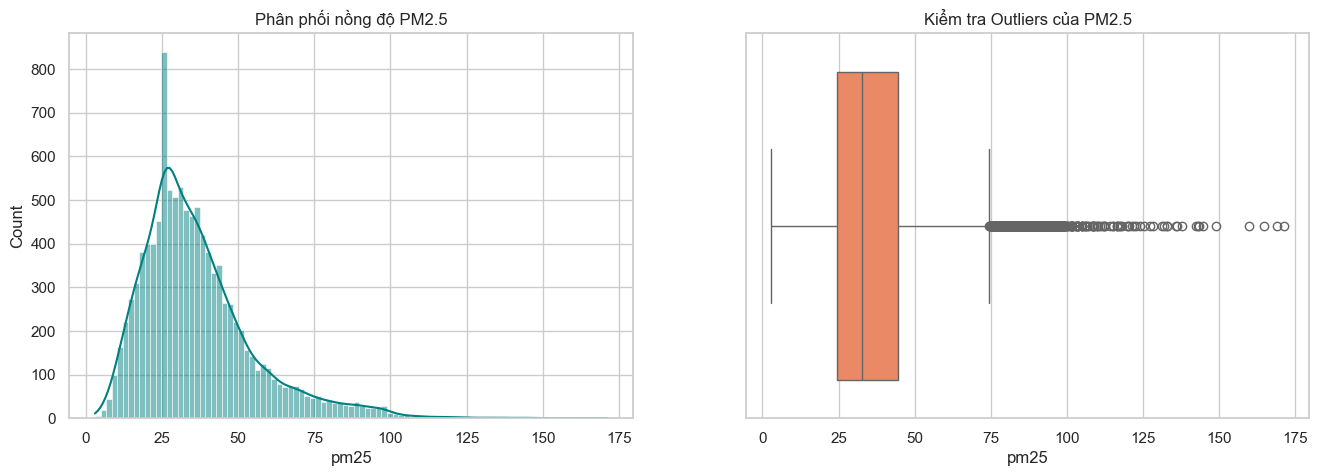


--- Kiểm định tính dừng (ADF Test) ---
ADF Statistic: -8.417
p-value: 0.000
=> Kết luận: Dữ liệu có tính dừng (Stationary).


In [16]:
# 2.1. Check missing values
print("--- Kiểm tra giá trị thiếu ---")
print(df.isnull().sum())

# 2.2. Check Distribution & Outliers
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df['pm25'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Phân phối nồng độ PM2.5')

sns.boxplot(x=df['pm25'], ax=axes[1], color='coral')
axes[1].set_title('Kiểm tra Outliers của PM2.5')
plt.show()

# 2.3. Kiểm tra tính dừng (ADF Test) - Quan trọng cho SARIMA
print("\n--- Kiểm định tính dừng (ADF Test) ---")
result = adfuller(df['pm25'].dropna())
print(f'ADF Statistic: {result[0]:.3f}')
print(f'p-value: {result[1]:.3f}')
if result[1] <= 0.05:
    print("=> Kết luận: Dữ liệu có tính dừng (Stationary).")
else:
    print("=> Kết luận: Dữ liệu không dừng, cần xử lý ở bước Preprocessing.")

3. Bivariate EDA (Phân tích hai biến)

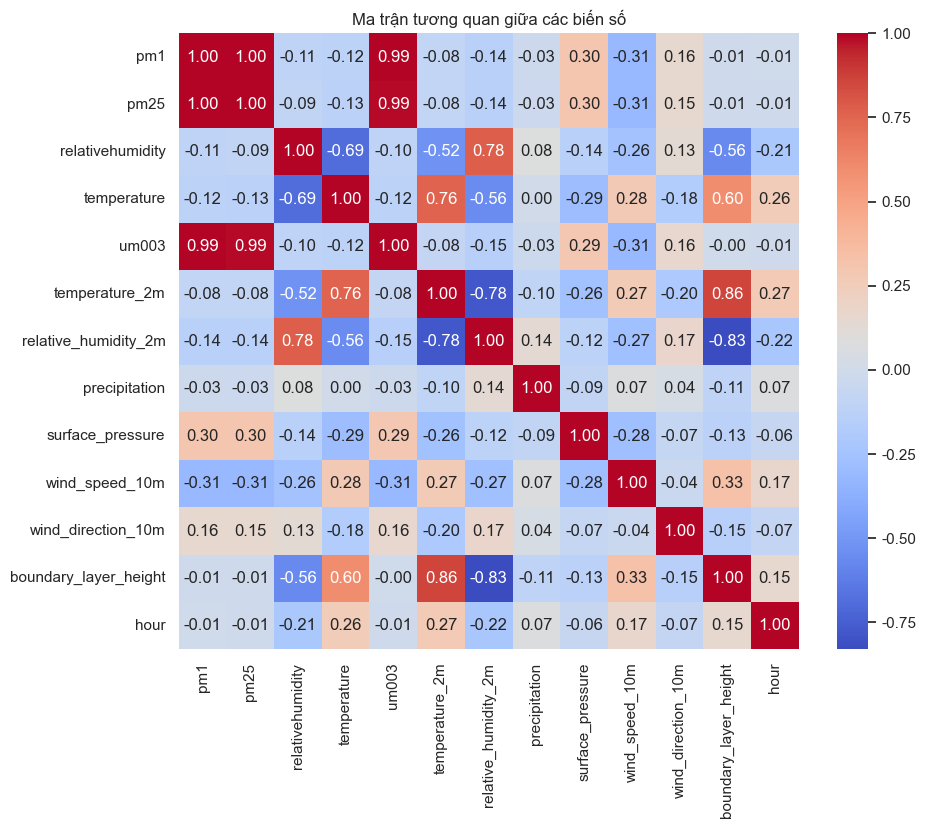

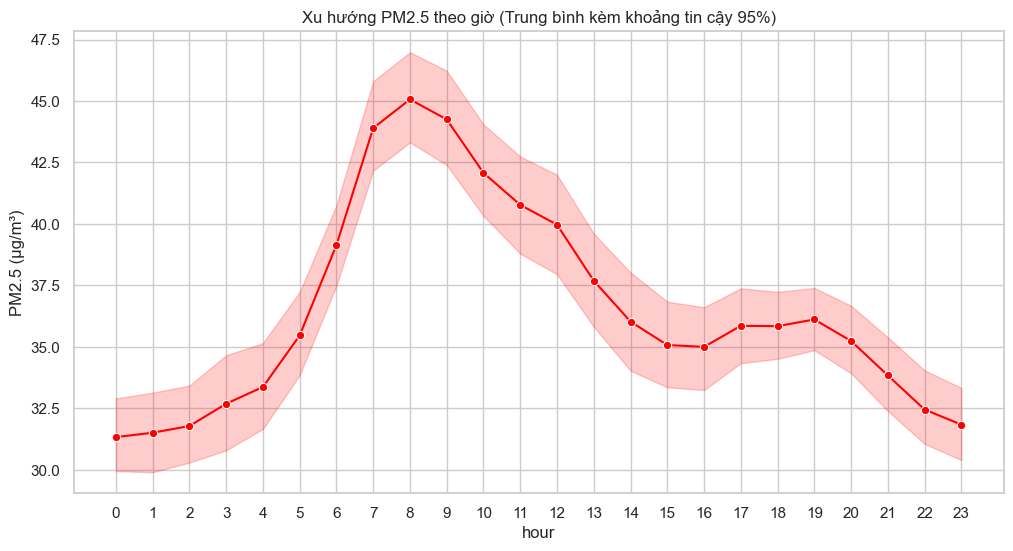

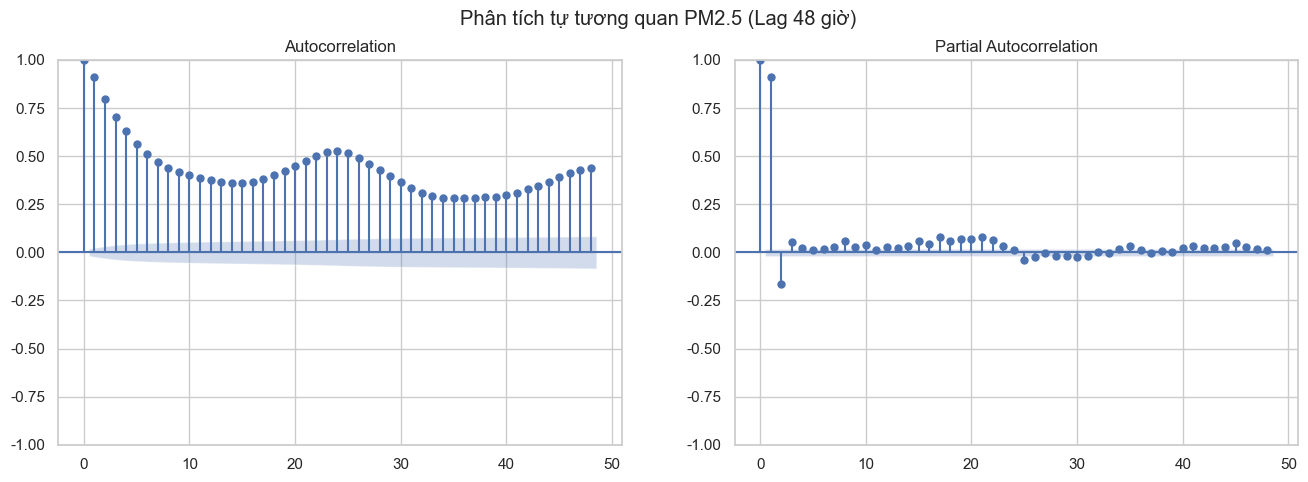

In [ ]:
# 3.1. Numerical-Numerical Correlation (Heatmap)
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

# 3.2. Categorical-Numerical (PM2.5 theo Giờ trong ngày)
df['hour'] = df.index.hour
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='hour', y='pm25', marker='o', color='red', errorbar=('ci', 95))
plt.title('Xu hướng PM2.5 theo giờ (Trung bình kèm khoảng tin cậy 95%)')
plt.xticks(range(24))
plt.ylabel('PM2.5 (µg/m³)')
plt.show()

# 3.3. Tự tương quan thời gian (ACF/PACF)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

df_resampled = df['pm25'].resample('h').mean().ffill()
plot_acf(df_resampled, lags=48, ax=ax1)
plot_pacf(df_resampled, lags=48, ax=ax2)
plt.suptitle('Phân tích tự tương quan PM2.5 (Lag 48 giờ)')
plt.show()

4. Multivariate EDA (Phân tích đa biến)

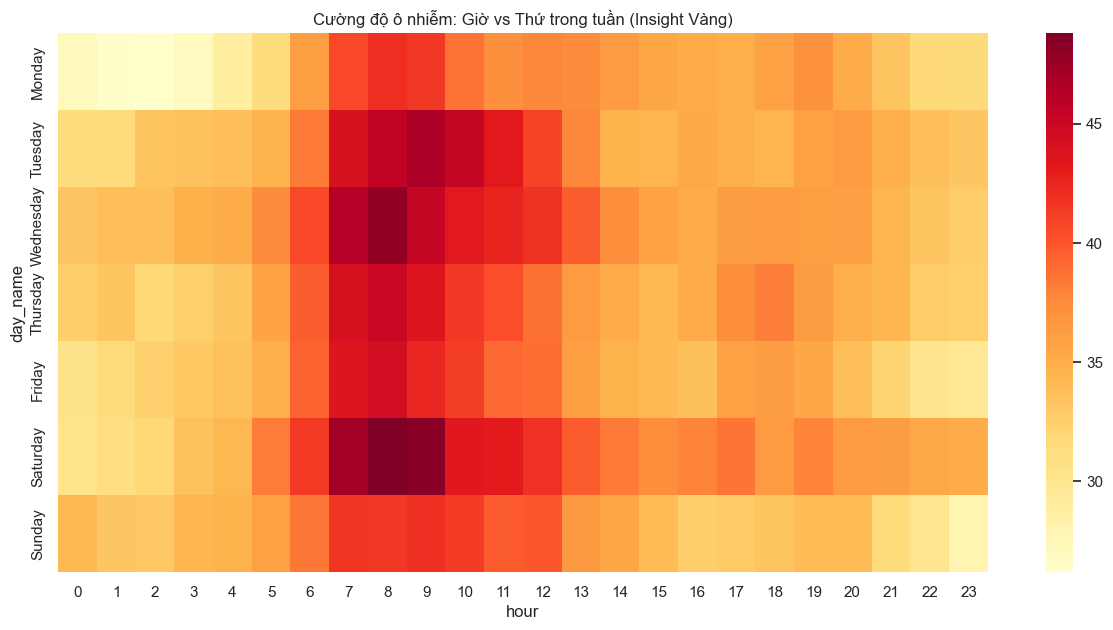

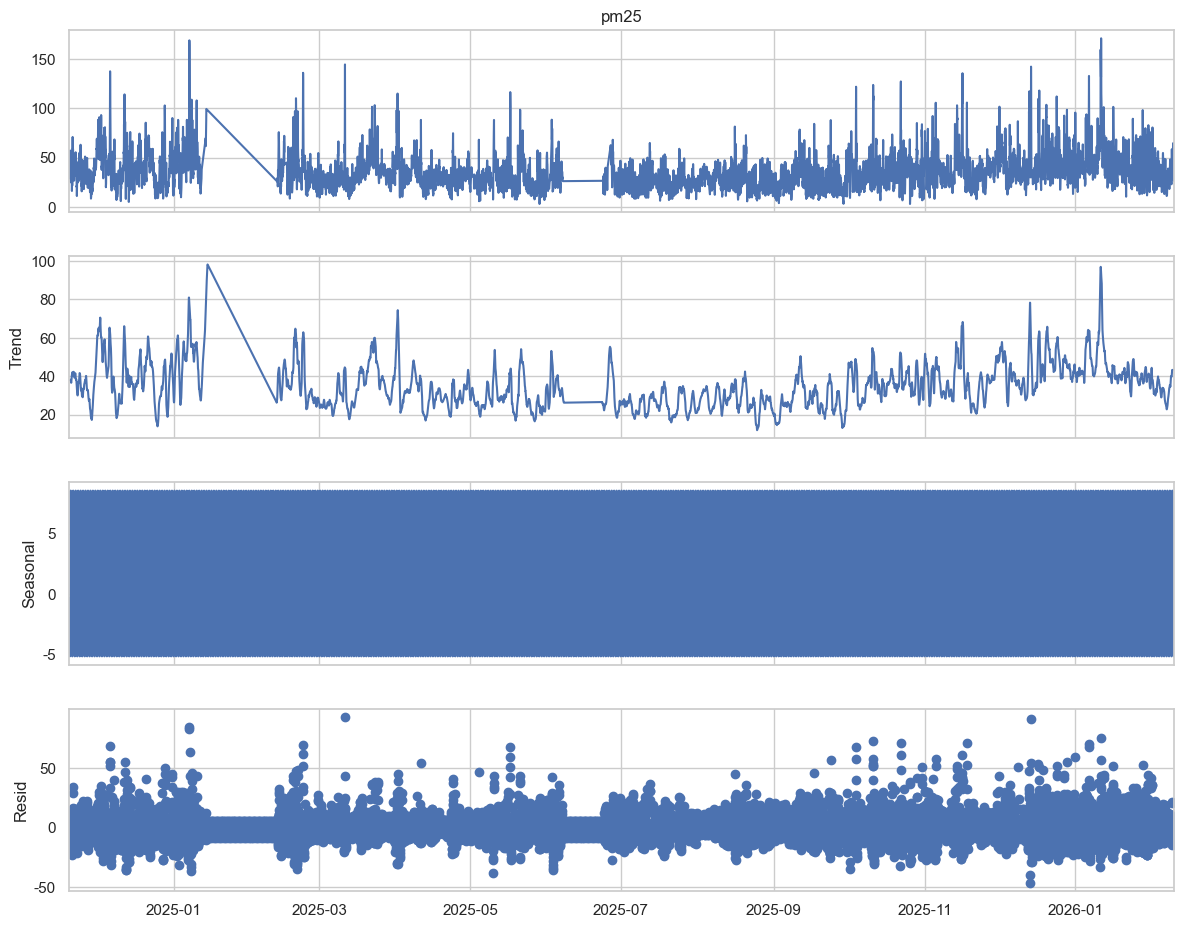

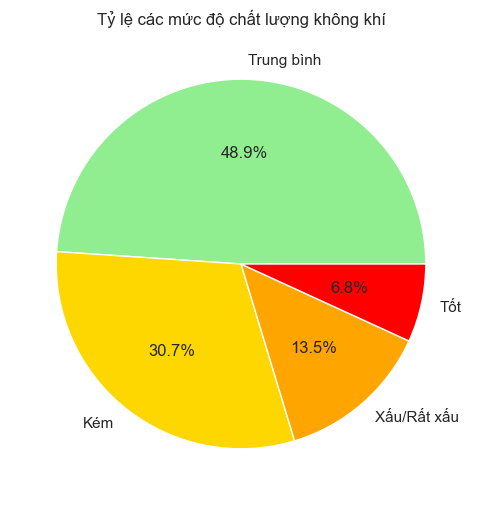

In [21]:
# 4.1. Feature Interaction: Heatmap Giờ vs Thứ trong tuần
df['day_name'] = df.index.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_table = df.pivot_table(values='pm25', index='day_name', columns='hour', aggfunc='mean').reindex(days_order)

plt.figure(figsize=(15, 7))
sns.heatmap(pivot_table, cmap='YlOrRd', annot=False)
plt.title('Cường độ ô nhiễm: Giờ vs Thứ trong tuần (Insight Vàng)')
plt.show()

# 4.2. Time-series Decomposition (Phân rã chuỗi thời gian)
result = seasonal_decompose(df_resampled, model='additive', period=24)
fig = result.plot()
fig.set_size_inches(12, 10)
plt.show()

# 4.3. Check Class Balance (Phân nhóm AQI)
def get_aqi_label(x):
    if x <= 15: return 'Tốt'
    elif x <= 35: return 'Trung bình'
    elif x <= 55: return 'Kém'
    else: return 'Xấu/Rất xấu'

df['aqi_label'] = df['pm25'].apply(get_aqi_label)
plt.figure(figsize=(8, 6))
df['aqi_label'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightgreen', 'gold', 'orange', 'red'])
plt.title('Tỷ lệ các mức độ chất lượng không khí')
plt.ylabel('')
plt.show()